In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csiborgtools

from hmf import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## FoF/Subfind

In [9]:
reader = csiborgtools.read.CSiBORG3Catalogue(3500, 129, paths=paths)

In [10]:
reader["totmass"]

2025-03-27 15:19:45,084 opening 32 blocks for snapshot `129`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 186.33it/s]


array([1.94771130e+15, 1.67762121e+15, 1.11887166e+15, ...,
       9.99117947e+10, 9.99117947e+10, 9.99117947e+10], dtype=float32)

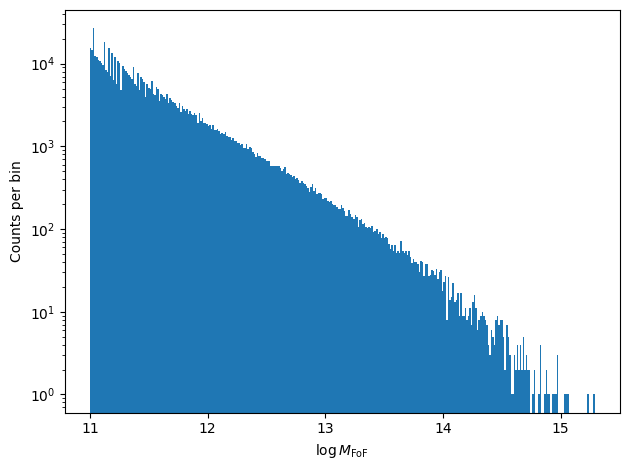

In [11]:
x = reader["totmass"]

plt.figure()
plt.hist(np.log10(x), bins="auto")

plt.xlabel(r"$\log M_{\rm FoF}$")
plt.ylabel("Counts per bin")
plt.yscale("log")

plt.tight_layout()
plt.show()

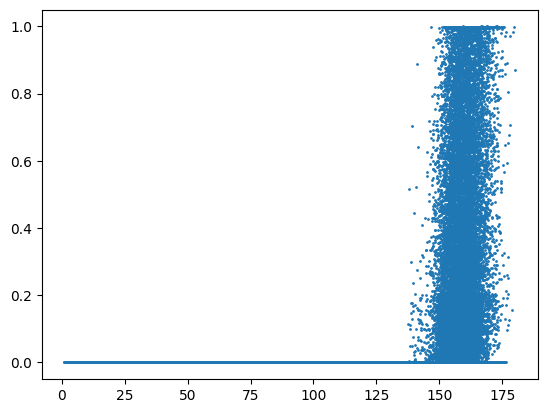

In [7]:
plt.figure()
plt.scatter(reader["dist"], reader["GroupContamination"], s=1)
plt.show()

In [8]:
x = reader["cartesian_pos"]

2025-03-27 12:57:13,256 opening 32 blocks for snapshot `129`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 213.49it/s]


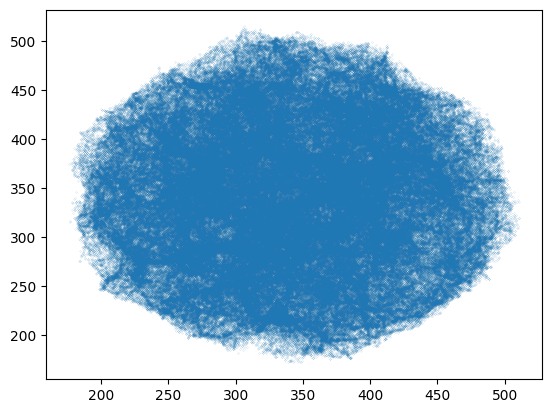

In [11]:
plt.figure()
plt.scatter(x[:, 0], x[:, 2], s=0.005)
plt.show()

## Rockstar

In [132]:
fdir = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/resimulations/mcmc_3500/output/Rockstar"
reader = csiborgtools.read.ReaderRockstar(fdir, 129, min_Mvir=1e12)

In [133]:
x = reader["log_Mvir"]

Reading a Rockstar catalogue from `/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/resimulations/mcmc_3500/output/Rockstar/out_129.list`.


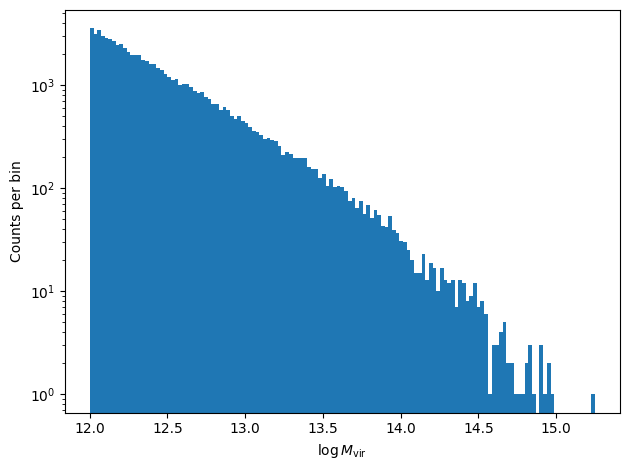

In [134]:
plt.figure()
plt.hist(x, bins="auto")
plt.yscale("log")
plt.xlabel(r"$\log M_{\rm vir}$")
plt.ylabel("Counts per bin")
plt.tight_layout()
plt.savefig("rockstar_mass_hist.png", dpi=300)

plt.show()

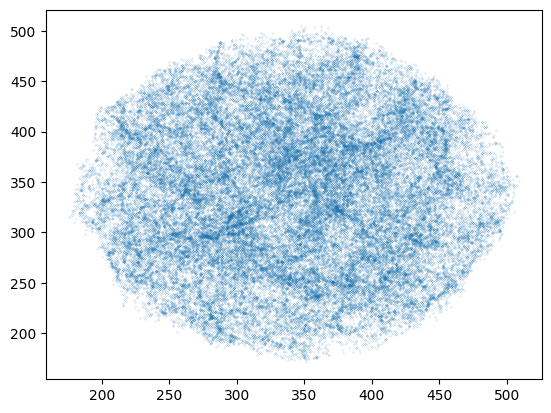

In [89]:
plt.figure()
plt.scatter(x[:, 0], x[:, 1], s=.01)
plt.show()

## Find Coma

In [29]:
reader = csiborgtools.read.CSiBORG3Catalogue(0, 130, paths=paths)

In [30]:
pos = reader["cartesian_pos"]
log_mass = np.log10(reader["totmass"])

2025-04-02 12:26:03,178 opening 32 blocks for snapshot `130`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 163.33it/s]


2025-04-02 12:26:03,382 opening 32 blocks for snapshot `130`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 195.67it/s]


In [52]:
prob_match = csiborgtools.match.MatchingProbability(pos, log_mass, )

cl = csiborgtools.clusters["Coma"]
ref_pos = cl.cartesian_pos(681.1)
ref_log_mass = 15

In [55]:
cdf, indxs = prob_match.match_halo(ref_pos, ref_log_mass, verbose=True)
cdf, indxs

Found 1 plausible matches in catalogue 0.
    1: CDF = 7.429e-06, index = 3, logM = 15.058 Msun / h, dx = 1.100 Mpc / h.



(np.float64(7.429178758178168e-06), np.int64(3))

In [ ]:
pos[indxs]

array([277.69333, 324.27426, 375.1567 ], dtype=float32)

In [51]:
reader["index"][indxs]

np.int32(3)

In [43]:
log_mass[indxs]

np.float32(15.058269)

In [42]:
ref_pos

array([278.60968248, 324.00768443, 374.61064765])